In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import sys, warnings
import plotly.io as pio
warnings.filterwarnings('ignore')
sys.path.append('..')

from src.preprocess import load_and_clean
from src.features import engineer_features, build_rfm

df = load_and_clean(filepath='../data/raw/online_retail_II.csv')
df = engineer_features(df)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Clean dataset: 779,425 rows
Shape: (779425, 17)
Columns: ['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'is_cancelled', 'total_price', 'revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'IsWeekend', 'Quarter']


In [2]:
monthly = df.groupby(['Year','Month'])['revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str)+'-'+monthly['Month'].astype(str).str.zfill(2)
fig = px.area(monthly, x='Period', y='revenue',
              title='📈 Monthly Revenue Trend',
              color_discrete_sequence=['#ff4d00'])
fig.show()

In [3]:
top20 = (df.groupby('description')['revenue']
         .sum().sort_values(ascending=False)
         .head(20).reset_index())
fig = px.bar(top20, x='revenue', y='description',
             orientation='h',
             title='🏆 Top 20 Products by Revenue',
             color='revenue', color_continuous_scale='Oranges')
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()

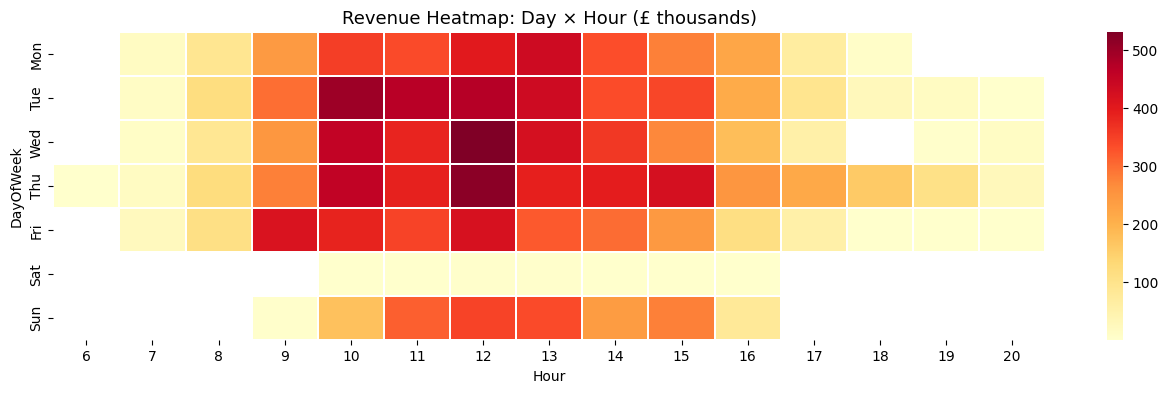

In [4]:
pivot = df.pivot_table(
    values='revenue', index='DayOfWeek',
    columns='Hour', aggfunc='sum')
fig, ax = plt.subplots(figsize=(16,4))
sns.heatmap(pivot/1000, cmap='YlOrRd',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            fmt='.0f', ax=ax, linewidths=0.3)
ax.set_title('Revenue Heatmap: Day × Hour (£ thousands)', fontsize=13)
plt.show()

In [5]:
by_country = df.groupby('country')['revenue'].sum().reset_index()
fig = px.bar(by_country.sort_values('revenue', ascending=False).head(10),
             x='country', y='revenue',
             title='🌍 Revenue by Country (Top 10)',
             color='revenue', color_continuous_scale='Blues')
fig.show()

In [6]:
clv = df.groupby('customer_id')['revenue'].sum().reset_index()
clv.columns = ['customer_id', 'TotalRevenue']
fig = px.histogram(clv[clv['TotalRevenue'] < 5000],
                   x='TotalRevenue', nbins=50,
                   title='💎 Customer Lifetime Value Distribution',
                   color_discrete_sequence=['#1a56db'])
fig.show()